In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/survey_data_labelled.csv"

In [3]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.columns 

Index(['Age', 'Gender', 'Occupation', 'Device_Type', 'Work_Productivity_Score',
       'Weekend_Screen_Time_Hours', 'Daily_Phone_Hours', 'Sleep_Hours',
       'Social_Media_Hours', 'Stress_Level', 'Caffeine_Intake_Cups'],
      dtype='object')

<h3> Irrelevant Columns

In [5]:
irrelevant = []

In [6]:
df = df.drop(columns=irrelevant)

<h3> Encoding Target Variable </h3>

In [7]:
le = LabelEncoder()
df['Stress_Level'] = le.fit_transform(df['Stress_Level'])

In [8]:
df.Stress_Level.value_counts()

Stress_Level
0    29
2    21
1     6
Name: count, dtype: int64

In [9]:
X = df.drop('Stress_Level', axis=1)
y = df['Stress_Level']

In [10]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={0: 100, 1: 100, 2: 100},  # <-- specify per class
    k_neighbors=2,
    random_state=42
)

In [14]:
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [15]:
X_train_scaled.shape

(39, 11)

In [16]:
X_train_smote.shape

(300, 11)

<h3> Random Forest Training 

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = SVC()

svm_model.fit(X_train_smote, y_train_smote)

SVC()

In [18]:
y_pred_svm = svm_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [19]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.5294117647058824
              precision    recall  f1-score   support

           0       0.75      0.67      0.71         9
           1       0.25      0.50      0.33         2
           2       0.40      0.33      0.36         6

    accuracy                           0.53        17
   macro avg       0.47      0.50      0.47        17
weighted avg       0.57      0.53      0.54        17



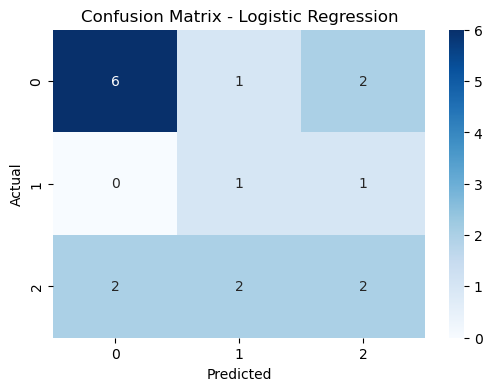

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()